In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

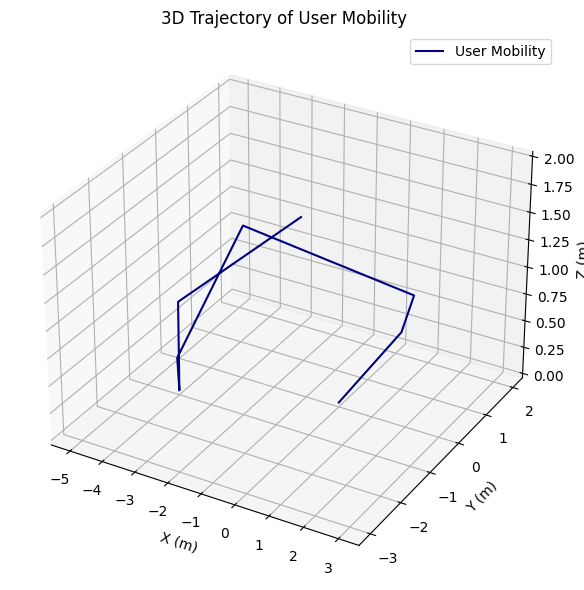

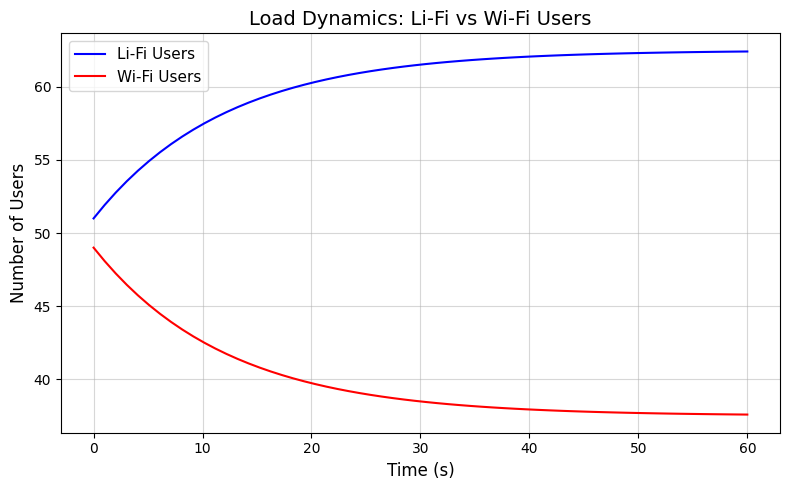

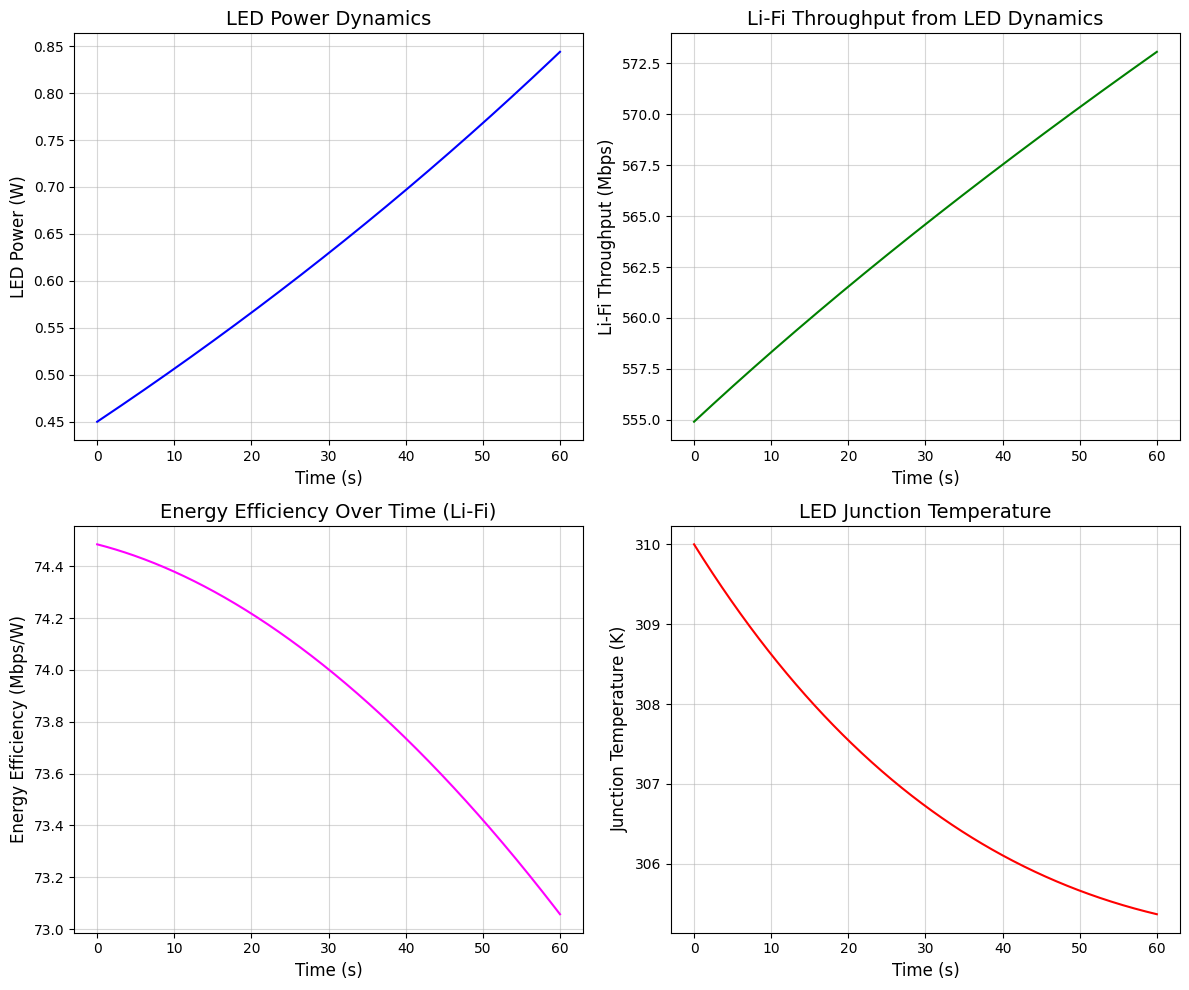

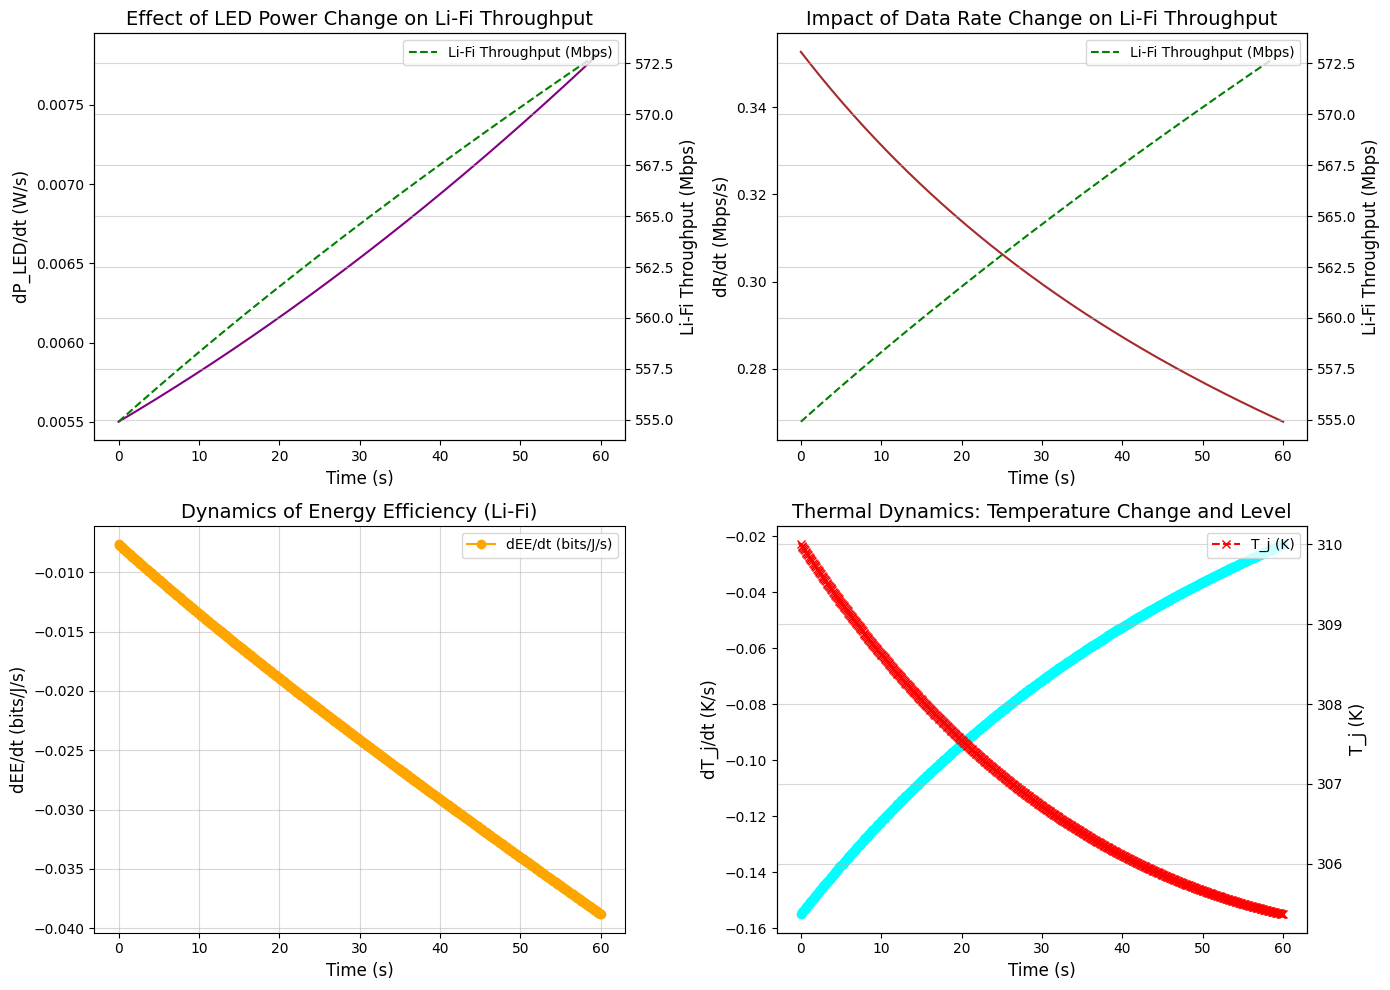

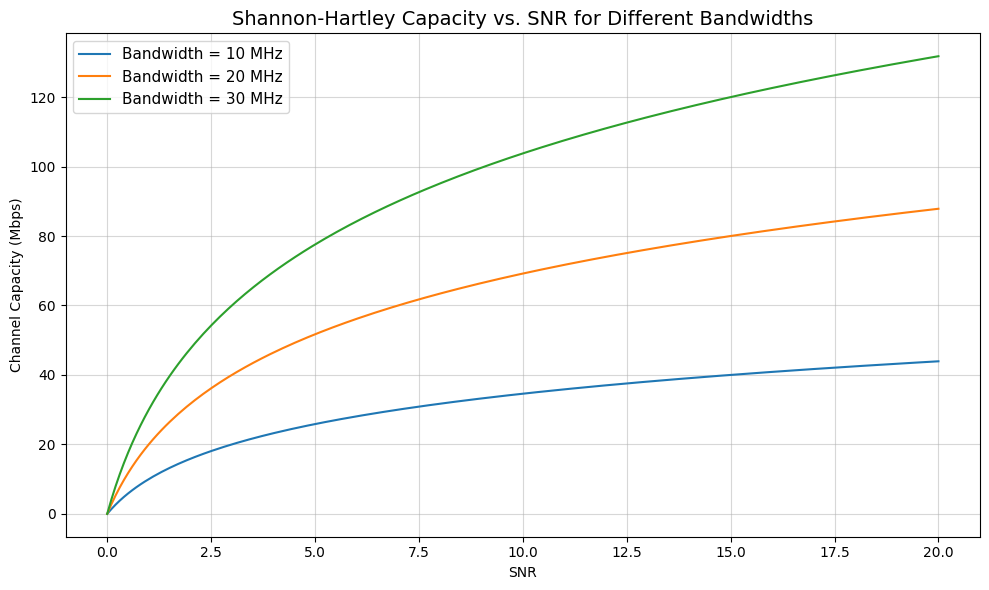

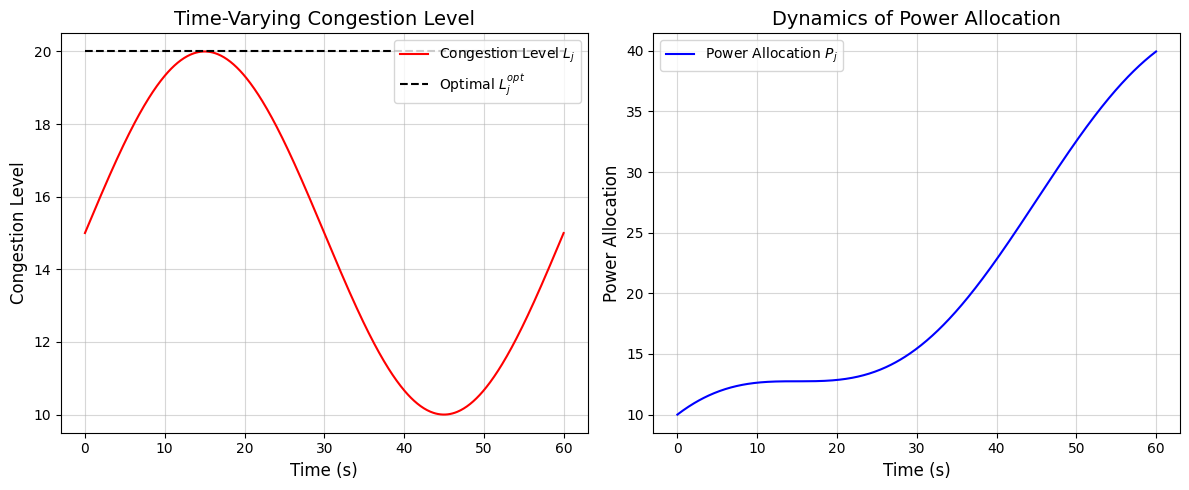

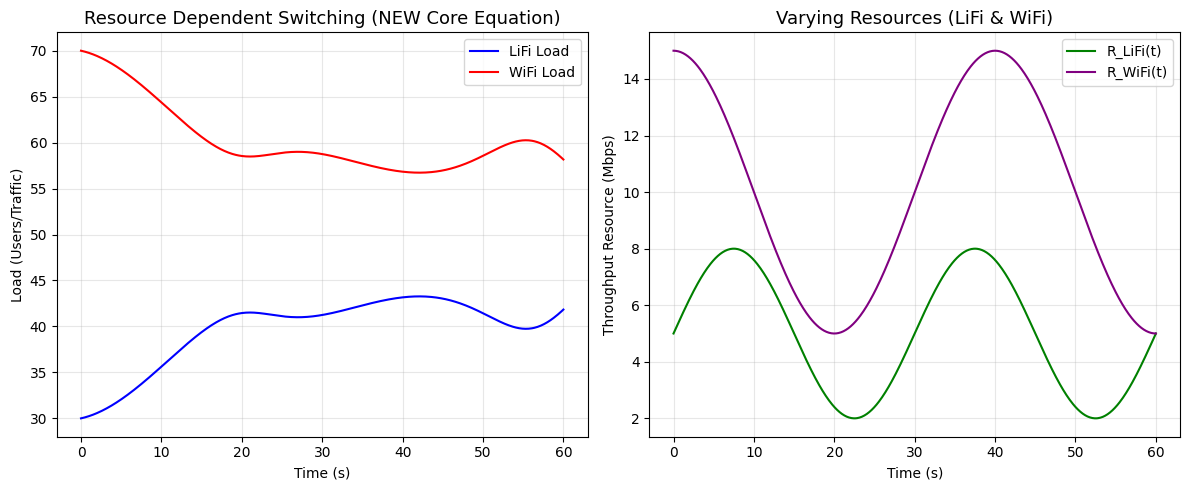

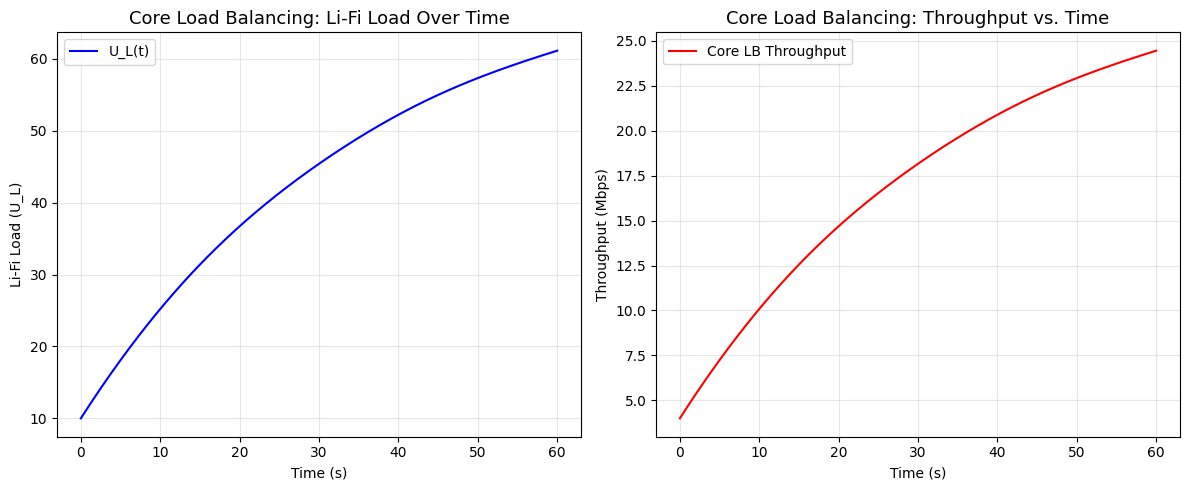

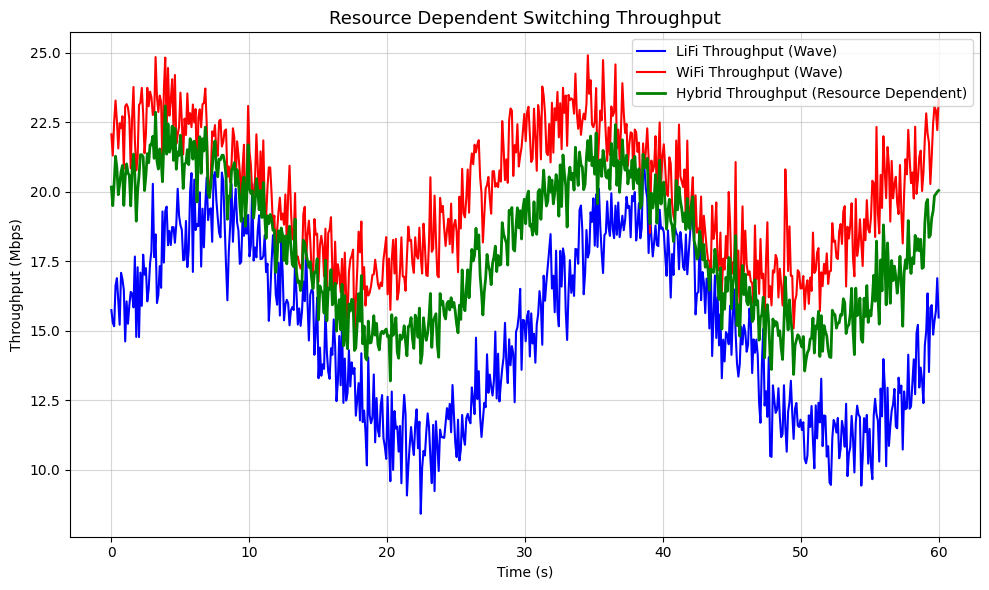

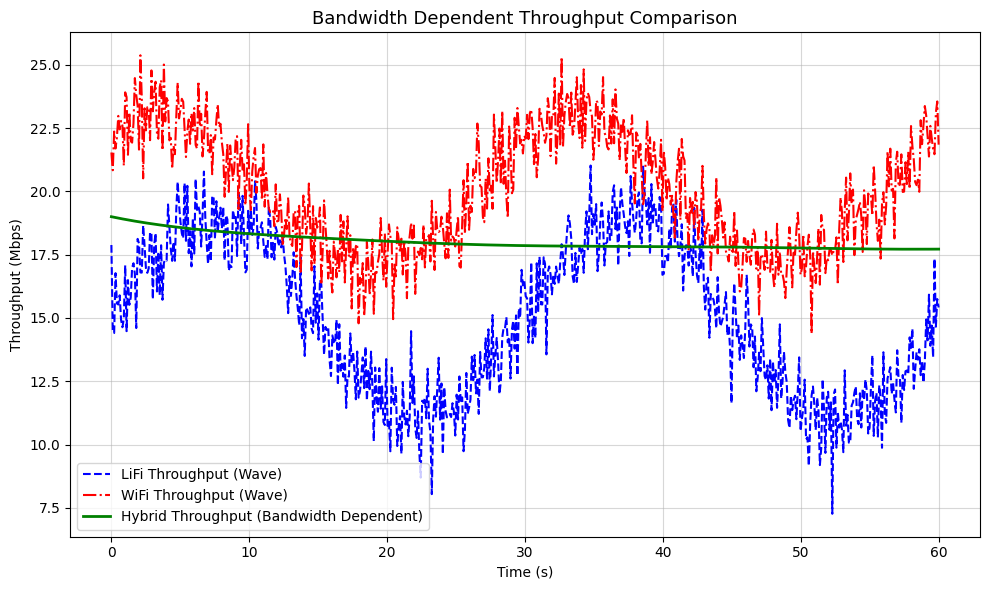

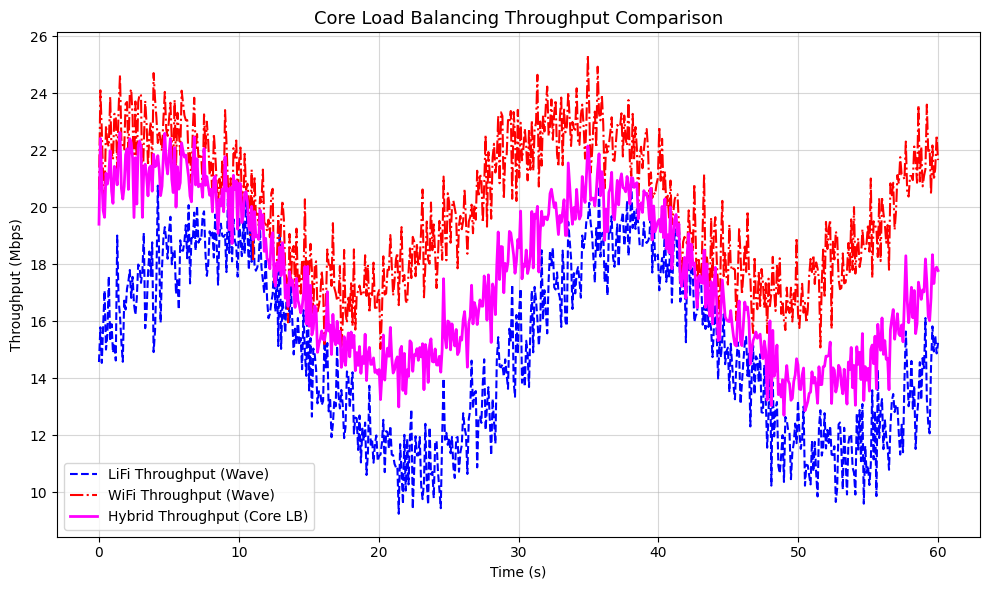

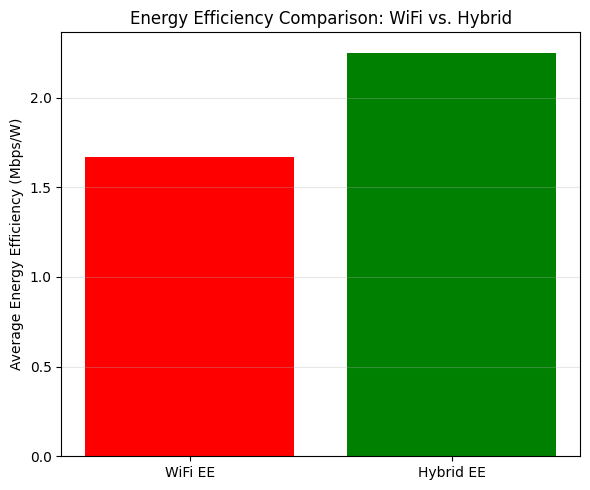

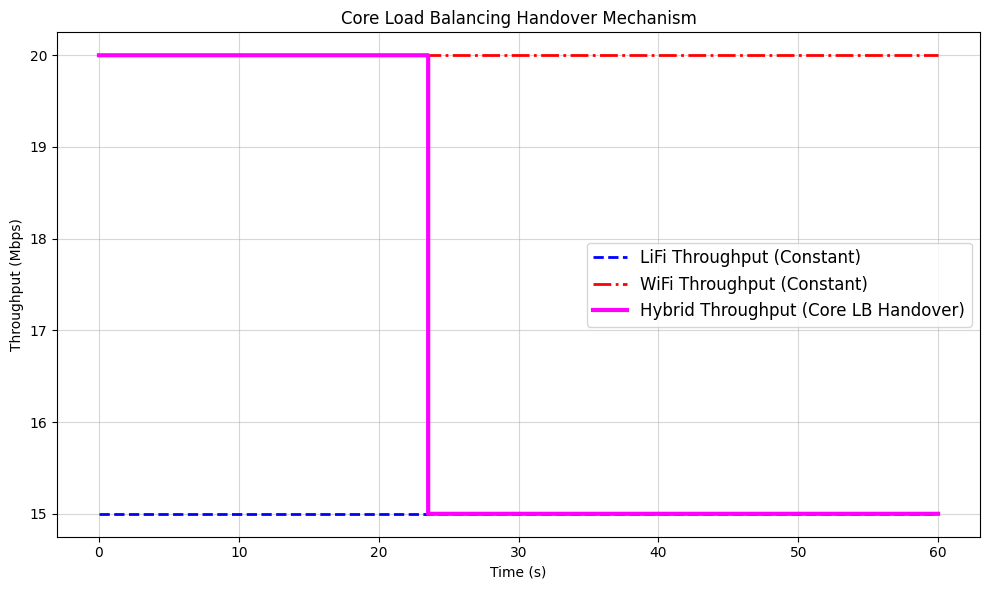

Core LB handover decision (1: LiFi, 0: WiFi):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

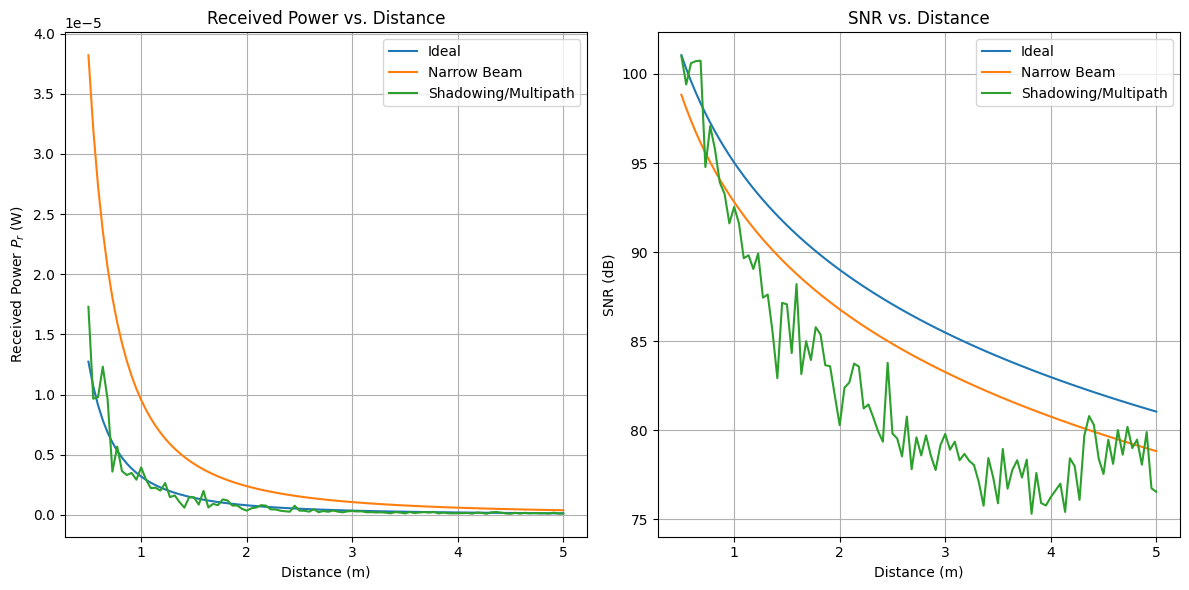

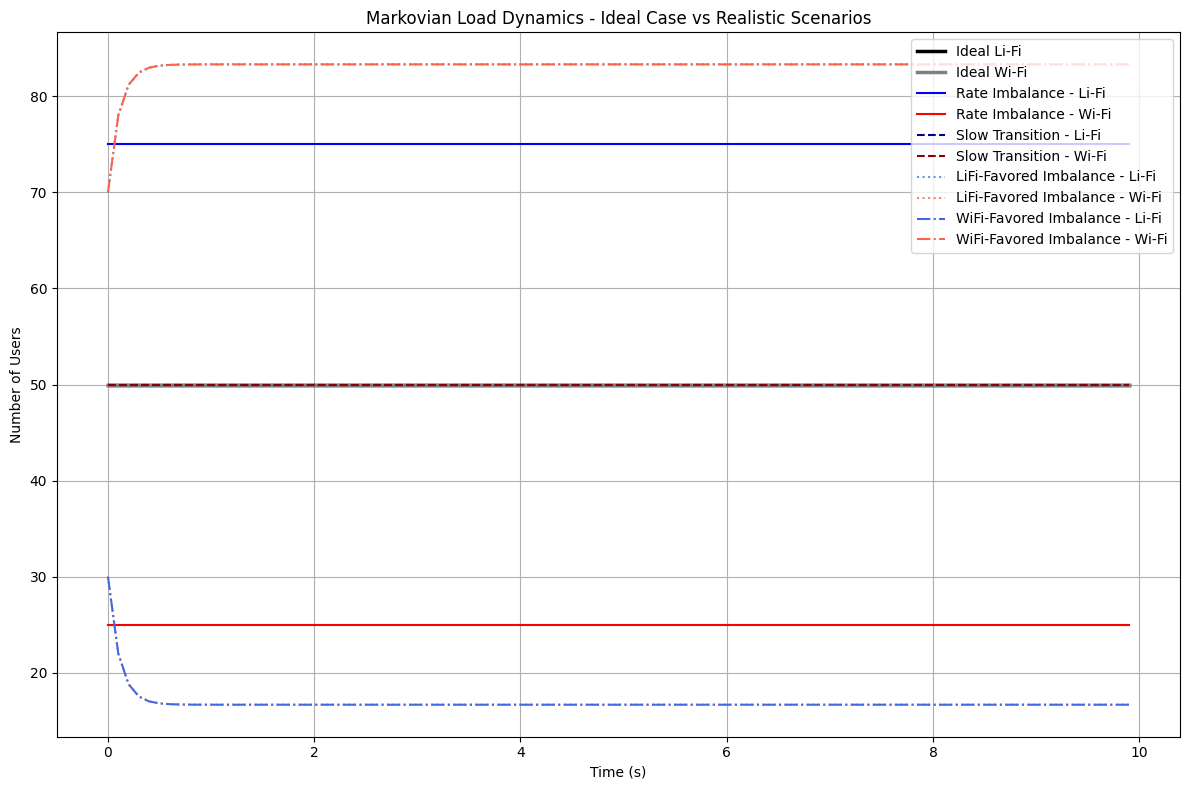


Four new graphs have been added:
1. Resource Dependent Switching Throughput (Hybrid, WiFi, LiFi realistic wave).
2. Bandwidth Dependent Throughput Comparison (Hybrid vs. LiFi and WiFi with realistic wave).
3. Core Load Balancing Throughput Comparison (Hybrid vs. LiFi and WiFi with realistic wave).
4. Bar chart comparing average energy efficiency between WiFi and Hybrid (Hybrid EE is improved).


In [17]:
import numpy as np
import matplotlib.pyplot as plt

#######################################
# PART 1: Mobility Model (3D Trajectory)
#######################################
class CentralController:
    def __init__(self):
        self.registered_users = []
    def user_registration(self, user):
        self.registered_users.append(user)
    def performance_metrics(self):
        pass

class LiFiWaypointMobilityModel:
    def __init__(self, initial_position, waypoints):
        self.position = np.array(initial_position, dtype=float)
        self.waypoints = np.array(waypoints, dtype=float)
        self.index = 0
    def update_position(self):
        if self.index < len(self.waypoints):
            self.position = self.waypoints[self.index]
            self.index += 1
        return self.position.copy()

# Example 3D trajectory (10 waypoints)
waypoints = [
    (0, 0, 0), (1, 1, 0.5), (2, 0, 1), (3, -1, 1.5), (-1, -2, 2),
    (-2, -3, 1), (-3, -2, 0.5), (-4, -1, 0), (-5, 0, 0.5), (-3, 2, 1)
]
time_steps_mobility = len(waypoints)
mobility_model = LiFiWaypointMobilityModel((0, 0, 0), waypoints)
trajectory = [mobility_model.update_position() for _ in range(time_steps_mobility)]
x_positions, y_positions, z_positions = zip(*trajectory)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_positions, y_positions, z_positions, label="User Mobility", color='navy')
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("3D Trajectory of User Mobility")
ax.legend()
plt.tight_layout()
plt.show()

#######################################
# PART 2: Markovian Load Dynamics
#######################################
class MarkovianLoadModel:
    def __init__(self, lambda_rate, mu_rate, initial_users_lifi, initial_users_wifi):
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.users_lifi = initial_users_lifi
        self.users_wifi = initial_users_wifi
    def update_users(self):
        dU_LiFi = self.lambda_rate * self.users_wifi - self.mu_rate * self.users_lifi
        dU_WiFi = self.mu_rate * self.users_lifi - self.lambda_rate * self.users_wifi
        self.users_lifi += dU_LiFi
        self.users_wifi += dU_WiFi
        return self.users_lifi, self.users_wifi

lambda_rate = 0.05
mu_rate = 0.03
initial_users_lifi = 50
initial_users_wifi = 50
markov_model = MarkovianLoadModel(lambda_rate, mu_rate, initial_users_lifi, initial_users_wifi)

time_values = np.linspace(0, 60, 60)  # 60-second simulation for load dynamics
lifi_users = []
wifi_users = []
for _ in time_values:
    u_lifi, u_wifi = markov_model.update_users()
    lifi_users.append(u_lifi)
    wifi_users.append(u_wifi)

plt.figure(figsize=(8,5))
plt.plot(time_values, lifi_users, label="Li-Fi Users", color='blue')
plt.plot(time_values, wifi_users, label="Wi-Fi Users", color='red')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.title("Load Dynamics: Li-Fi vs Wi-Fi Users", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

#######################################
# PART 3: Throughput Models (Wi-Fi Only)
#######################################
def wifi_throughput_model(t_vals, Pt=50, d0=1.0, n=3.0, shadow_std=2.0, noise_floor=1):
    """
    Wi-Fi throughput model:
      - distance(t) = 3 + 2*sin(2*pi*t/30)
      - Throughput = B*log2(1+SINR), with path loss, shadowing, and fading.
    """
    distance = 3 + 2 * np.sin(2 * np.pi * t_vals / 30)
    path_loss_db = 10 * n * np.log10(distance / d0)
    shadowing_db = np.random.normal(0, shadow_std, len(t_vals))
    total_loss_db = path_loss_db + shadowing_db
    total_loss_lin = 10 ** (-total_loss_db / 10)
    fading = np.random.rayleigh(scale=1.0, size=len(t_vals))
    SINR = (Pt * total_loss_lin * fading) / (noise_floor + 1e-9)
    bandwidth = 20  # MHz
    throughput = bandwidth * np.log2(1 + SINR)
    throughput += np.random.normal(0, 1, len(t_vals))
    return throughput

# Wi-Fi throughput over 60s
t_sim = 60
time_values = np.linspace(0, t_sim, 60)
wifi_throughput_vals = wifi_throughput_model(time_values, Pt=50, d0=1.0, n=3.0, shadow_std=2.0, noise_floor=1)

#######################################
# PART 4: LED Energy Efficiency Model (ODE Simulation)
#######################################
T_sim_LED = 60
dt_LED = 0.1
N_steps_LED = int(T_sim_LED / dt_LED)
eta = 0.8
I0 = 0.5
M0 = 0.2
dI_dt = 0.005
dM_dt = 0.002
B = 20
N0 = 1e-9
G = 10
P_circuit = 5
P_receiver = 2
C_th = 10
T_a = 300
R_th = 5

I = I0
M = M0
P_LED = eta * I + M * I**2
SNR = G * P_LED / (N0 * B)
R_led = B * np.log2(1 + SNR)
P_total = P_LED + P_circuit + P_receiver
EE = R_led / P_total
T_j = 310

time_arr_LED = np.linspace(0, T_sim_LED, N_steps_LED)
I_arr = np.zeros(N_steps_LED)
M_arr = np.zeros(N_steps_LED)
P_LED_arr = np.zeros(N_steps_LED)
R_arr = np.zeros(N_steps_LED)
EE_arr = np.zeros(N_steps_LED)
Tj_arr = np.zeros(N_steps_LED)
P_total_arr = np.zeros(N_steps_LED)
dP_LED_dt_arr = np.zeros(N_steps_LED)
dR_dt_arr = np.zeros(N_steps_LED)
dEE_dt_arr = np.zeros(N_steps_LED)
dTj_dt_arr = np.zeros(N_steps_LED)

for i in range(N_steps_LED):
    I_arr[i] = I
    M_arr[i] = M
    P_LED_arr[i] = P_LED
    R_arr[i] = R_led
    EE_arr[i] = EE
    Tj_arr[i] = T_j
    P_total_arr[i] = P_total
    
    dP_LED_dt = eta * dI_dt + 2 * M * I * dI_dt + I**2 * dM_dt
    dR_dt = (G / (N0 * np.log(2))) * (1 / (1 + SNR)) * dP_LED_dt
    dP_total_dt = dP_LED_dt
    dEE_dt = (dR_dt * P_total - R_led * dP_total_dt) / (P_total**2)
    dTj_dt = (1 / C_th) * (P_LED - (T_j - T_a) / R_th)
    
    dP_LED_dt_arr[i] = dP_LED_dt
    dR_dt_arr[i] = dR_dt
    dEE_dt_arr[i] = dEE_dt
    dTj_dt_arr[i] = dTj_dt
    
    I += dI_dt * dt_LED
    M += dM_dt * dt_LED
    P_LED += dP_LED_dt * dt_LED
    R_led += dR_dt * dt_LED
    P_total = P_LED + P_circuit + P_receiver
    EE += dEE_dt * dt_LED
    T_j += dTj_dt * dt_LED
    SNR = G * P_LED / (N0 * B)

plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.plot(time_arr_LED, P_LED_arr, color='blue')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('LED Power (W)', fontsize=12)
plt.title("LED Power Dynamics", fontsize=14)
plt.grid(alpha=0.5)
plt.subplot(2,2,2)
plt.plot(time_arr_LED, R_arr, color='green')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Li-Fi Throughput (Mbps)', fontsize=12)
plt.title("Li-Fi Throughput from LED Dynamics", fontsize=14)
plt.grid(alpha=0.5)
plt.subplot(2,2,3)
plt.plot(time_arr_LED, EE_arr, color='magenta')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Energy Efficiency (Mbps/W)', fontsize=12)
plt.title("Energy Efficiency Over Time (Li-Fi)", fontsize=14)
plt.grid(alpha=0.5)
plt.subplot(2,2,4)
plt.plot(time_arr_LED, Tj_arr, color='red')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Junction Temperature (K)', fontsize=12)
plt.title("LED Junction Temperature", fontsize=14)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

#######################################
# PART 5: Analysis of ODE Effects on Throughput
#######################################
wifi_throughput_ode = wifi_throughput_model(time_arr_LED, Pt=50, d0=1.0, n=3.0, shadow_std=2.0, noise_floor=1)

plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
plt.plot(time_arr_LED, dP_LED_dt_arr, color='purple', label="dP_LED/dt (W/s)")
plt.ylabel("dP_LED/dt (W/s)", fontsize=12)
plt.xlabel("Time (s)", fontsize=12)
ax1 = plt.gca().twinx()
ax1.plot(time_arr_LED, R_arr, color='green', linestyle='--', label="Li-Fi Throughput (Mbps)")
ax1.set_ylabel("Li-Fi Throughput (Mbps)", fontsize=12)
plt.title("Effect of LED Power Change on Li-Fi Throughput", fontsize=14)
plt.legend(loc="upper right", fontsize=10)
plt.grid(alpha=0.5)
plt.subplot(2,2,2)
plt.plot(time_arr_LED, dR_dt_arr, color='brown', label="dR/dt (Mbps/s)")
plt.ylabel("dR/dt (Mbps/s)", fontsize=12)
plt.xlabel("Time (s)", fontsize=12)
ax2 = plt.gca().twinx()
ax2.plot(time_arr_LED, R_arr, color='green', linestyle='--', label="Li-Fi Throughput (Mbps)")
ax2.set_ylabel("Li-Fi Throughput (Mbps)", fontsize=12)
plt.title("Impact of Data Rate Change on Li-Fi Throughput", fontsize=14)
plt.legend(loc="upper right", fontsize=10)
plt.grid(alpha=0.5)
plt.subplot(2,2,3)
plt.plot(time_arr_LED, dEE_dt_arr, color='orange', marker='o', label="dEE/dt (bits/J/s)")
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("dEE/dt (bits/J/s)", fontsize=12)
plt.title("Dynamics of Energy Efficiency (Li-Fi)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.5)
plt.subplot(2,2,4)
plt.plot(time_arr_LED, dTj_dt_arr, color='cyan', marker='o', label="dT_j/dt (K/s)")
plt.ylabel("dT_j/dt (K/s)", fontsize=12)
plt.xlabel("Time (s)", fontsize=12)
ax4 = plt.gca().twinx()
ax4.plot(time_arr_LED, Tj_arr, color='red', linestyle='--', marker='x', label="T_j (K)")
ax4.set_ylabel("T_j (K)", fontsize=12)
plt.title("Thermal Dynamics: Temperature Change and Level", fontsize=14)
plt.legend(loc="upper right", fontsize=10)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

#######################################
# PART 7: Shannon-Hartley Capacity
#######################################
def shannon_capacity(SNR, bandwidth):
    return bandwidth * np.log2(1 + SNR)

SNR_range = np.linspace(0, 20, 200)
bandwidths = [10, 20, 30]
plt.figure(figsize=(10,6))
for bw in bandwidths:
    capacity = shannon_capacity(SNR_range, bw)
    plt.plot(SNR_range, capacity, label=f"Bandwidth = {bw} MHz")
plt.xlabel("SNR")
plt.ylabel("Channel Capacity (Mbps)")
plt.title("Shannon-Hartley Capacity vs. SNR for Different Bandwidths", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

#######################################
# PART 8: Proportional Congestion & Power Allocation Model
#######################################
T_sim_PC = 60
dt_PC = 0.1
N_steps_PC = int(T_sim_PC / dt_PC)
delta = 0.1
L_opt = 20
t_PC = np.linspace(0, T_sim_PC, N_steps_PC)
L_j = 15 + 5 * np.sin(2 * np.pi * t_PC / T_sim_PC)
P_j = 10.0
P_j_arr = np.zeros(N_steps_PC)
for i in range(N_steps_PC):
    P_j_arr[i] = P_j
    dP_dt = delta * (L_opt - L_j[i])
    P_j += dP_dt * dt_PC
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(t_PC, L_j, color='red', label="Congestion Level $L_j$")
plt.hlines(L_opt, t_PC[0], t_PC[-1], colors='black', linestyles='--', label="Optimal $L_j^{opt}$")
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Congestion Level", fontsize=12)
plt.title("Time-Varying Congestion Level", fontsize=14)
plt.legend()
plt.grid(alpha=0.5)
plt.subplot(1,2,2)
plt.plot(t_PC, P_j_arr, color='blue', label="Power Allocation $P_j$")
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Power Allocation", fontsize=12)
plt.title("Dynamics of Power Allocation", fontsize=14)
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

#######################################
# PART 9: Resource Dependent Switching (NEW "Core Equation")
#######################################
def dLiFi_dt(LiFi, WiFi, R_LiFi, R_WiFi, alpha, beta):
    denom = R_LiFi + R_WiFi
    if denom <= 1e-12:
        return 0.0
    in_flow = alpha * WiFi * (R_LiFi / denom)
    out_flow = beta  * LiFi * (R_WiFi / denom)
    return in_flow - out_flow

def dWiFi_dt(LiFi, WiFi, R_LiFi, R_WiFi, alpha, beta):
    denom = R_LiFi + R_WiFi
    if denom <= 1e-12:
        return 0.0
    in_flow = beta  * LiFi * (R_WiFi / denom)
    out_flow = alpha * WiFi * (R_LiFi / denom)
    return in_flow - out_flow

T_sim_R = 60
dt_R = 0.1
N_steps_R = int(T_sim_R / dt_R)
alpha_RD = 0.05
beta_RD  = 0.03
LiFi_0 = 30.0
WiFi_0 = 70.0
LiFi_vals = np.zeros(N_steps_R)
WiFi_vals = np.zeros(N_steps_R)
LiFi_vals[0] = LiFi_0
WiFi_vals[0] = WiFi_0
time_R = np.linspace(0, T_sim_R, N_steps_R)
R_LiFi_arr = 5 + 3 * np.sin(2 * np.pi * time_R / 30.0)
R_WiFi_arr = 10 + 5 * np.cos(2 * np.pi * time_R / 40.0)
for i in range(N_steps_R - 1):
    LiFi_i = LiFi_vals[i]
    WiFi_i = WiFi_vals[i]
    R_LiFi_i = R_LiFi_arr[i]
    R_WiFi_i = R_WiFi_arr[i]
    dLi = dLiFi_dt(LiFi_i, WiFi_i, R_LiFi_i, R_WiFi_i, alpha_RD, beta_RD)
    dWi = dWiFi_dt(LiFi_i, WiFi_i, R_LiFi_i, R_WiFi_i, alpha_RD, beta_RD)
    LiFi_vals[i+1] = LiFi_i + dLi*dt_R
    WiFi_vals[i+1] = WiFi_i + dWi*dt_R
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(time_R, LiFi_vals, label="LiFi Load", color='blue')
plt.plot(time_R, WiFi_vals, label="WiFi Load", color='red')
plt.title("Resource Dependent Switching (NEW Core Equation)", fontsize=13)
plt.xlabel("Time (s)")
plt.ylabel("Load (Users/Traffic)")
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(time_R, R_LiFi_arr, label="R_LiFi(t)", color='green')
plt.plot(time_R, R_WiFi_arr, label="R_WiFi(t)", color='purple')
plt.title("Varying Resources (LiFi & WiFi)", fontsize=13)
plt.xlabel("Time (s)")
plt.ylabel("Throughput Resource (Mbps)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#######################################
# PART 10: Core Load Balancing ("Core Equation")
#######################################
def dU_L_dt(U_L, U_W, t, params):
    lambda_L = params["lambda_L"]
    mu_L     = params["mu_L"]
    H_o      = params["H_o"]
    v        = params["v"]
    v0       = params["v0"]
    alpha_CB = params["alpha_CB"]
    gamma_CB = params["gamma_CB"]
    G_L      = params["G_L"]
    G_W      = params["G_W"]
    B_L      = params["B_L"]
    B_L_used = params["B_L_used_func"](t)
    mobility_term = H_o * np.exp(-v/v0) * U_L
    load_term = gamma_CB * ((U_L / G_L) + (U_W / G_W))
    return (lambda_L - mu_L * U_L - mobility_term + alpha_CB * (B_L_used / B_L) - load_term)

T_sim_CB = 60
dt_CB = 0.1
N_steps_CB = int(T_sim_CB/dt_CB)
params_CB = {
    "lambda_L":   2.0,
    "mu_L":       0.02,
    "H_o":        0.01,
    "v":          1.0,
    "v0":         2.0,
    "alpha_CB":   0.1,
    "gamma_CB":   0.05,
    "G_L":        50.0,
    "G_W":        70.0,
    "B_L":        20.0,
    "B_L_used_func": lambda t: 5 + 3 * np.sin(2 * np.pi * t / 30.0)
}
U_W_const = 40.0
time_CB = np.linspace(0, T_sim_CB, N_steps_CB)
U_L_vals_CB = np.zeros(N_steps_CB)
U_L_vals_CB[0] = 10.0
for i in range(N_steps_CB-1):
    t_i = time_CB[i]
    dU_L = dU_L_dt(U_L_vals_CB[i], U_W_const, t_i, params_CB)
    U_L_vals_CB[i+1] = U_L_vals_CB[i] + dU_L * dt_CB
B_L_used_arr = [params_CB["B_L_used_func"](t) for t in time_CB]
CLB_throughput = 0.4 * U_L_vals_CB
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(time_CB, U_L_vals_CB, color='blue', label="U_L(t)")
plt.xlabel("Time (s)")
plt.ylabel("Li-Fi Load (U_L)")
plt.title("Core Load Balancing: Li-Fi Load Over Time", fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.subplot(1,2,2)
plt.plot(time_CB, CLB_throughput, color='red', label="Core LB Throughput")
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Mbps)")
plt.title("Core Load Balancing: Throughput vs. Time", fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#######################################
# PART 11: New Bandwidth Equation 
#######################################
def HL_to_W(BL_used, BW, k1=0.02, n=1.0):
    if BW <= 1e-9:
        return 0.0
    ratio = BL_used / BW
    return k1 * (ratio**n)

def HW_to_L(BW_used, BL, k2=0.01):
    if BL <= 1e-9:
        return 0.0
    ratio = BW_used / BL
    return k2 * max(0, 1.0 - ratio)

def dU_L_newBW(U_L, U_W, BL_used, BW_used, params):
    lam_L = params["lambda_L"]
    mu_L  = params["mu_L"]
    k1    = params["k1"]
    k2    = params["k2"]
    n_exp = params["n_exp"]
    HLW = HL_to_W(BL_used, BW_used, k1, n_exp)
    HWL = HW_to_L(BW_used, BL_used, k2)
    return lam_L - mu_L * U_L - HLW * U_L + HWL * U_W

T_sim_newBW = 60
dt_newBW = 0.1
N_steps_newBW = int(T_sim_newBW / dt_newBW)
time_newBW = np.linspace(0, T_sim_newBW, N_steps_newBW)
params_newBW = {
    "lambda_L": 2.0,
    "mu_L":     0.05,
    "k1":       0.02,
    "k2":       0.01,
    "n_exp":    1.0
}
U_W_const_newBW = 40.0
U_L_vals_newBW = np.zeros(N_steps_newBW)
U_L_vals_newBW[0] = 10.0
BL_total = 20.0
BW_total = 25.0
BL_used_new = 5 + 3 * np.sin(2 * np.pi * time_newBW / 30.0)
BW_used_arr = 10 + 2 * np.cos(2 * np.pi * time_newBW / 40.0)
for i in range(N_steps_newBW-1):
    U_L_i = U_L_vals_newBW[i]
    BL_used_i = BL_used_new[i]
    BW_used_i = BW_used_arr[i]
    dU = dU_L_newBW(U_L_i, U_W_const_newBW, BL_used_i, BW_used_i, params_newBW)
    U_L_vals_newBW[i+1] = U_L_i + dU * dt_newBW
LiFi_th_const = 15.0
WiFi_th_const = 20.0
hybrid_th_newBW = np.zeros(N_steps_newBW)
for i in range(N_steps_newBW):
    total_load = U_L_vals_newBW[i] + U_W_const_newBW
    if total_load < 1e-9:
        hybrid_th_newBW[i] = 0.0
    else:
        frac_L = U_L_vals_newBW[i] / total_load
        frac_W = U_W_const_newBW / total_load
        hybrid_th_newBW[i] = frac_L * LiFi_th_const + frac_W * WiFi_th_const

#######################################
# PART 12: Graphs for Throughput Comparisons
#######################################
# Graph 1: Resource Dependent Switching Throughput with realistic wave
t_resource = time_R
noise1 = np.random.normal(0, 1, len(t_resource))
noise2 = np.random.normal(0, 1, len(t_resource))
LiFi_th_wave = 15 + 4 * np.sin(2 * np.pi * t_resource / 30) + noise1
WiFi_th_wave = 20 + 3 * np.sin(2 * np.pi * t_resource / 30 + np.pi/4) + noise2
Hybrid_th_resource = (np.array(LiFi_vals) / (np.array(LiFi_vals) + np.array(WiFi_vals))) * LiFi_th_wave + (np.array(WiFi_vals) / (np.array(LiFi_vals) + np.array(WiFi_vals))) * WiFi_th_wave
plt.figure(figsize=(10,6))
plt.plot(t_resource, LiFi_th_wave, label="LiFi Throughput (Wave)", color='blue')
plt.plot(t_resource, WiFi_th_wave, label="WiFi Throughput (Wave)", color='red')
plt.plot(t_resource, Hybrid_th_resource, label="Hybrid Throughput (Resource Dependent)", color='green', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Mbps)")
plt.title("Resource Dependent Switching Throughput", fontsize=13)
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Graph 2: Bandwidth Dependent Throughput Comparison with realistic wave
noise3 = np.random.normal(0, 1, len(time_newBW))
noise4 = np.random.normal(0, 1, len(time_newBW))
LiFi_th_BW = 15 + 4 * np.sin(2 * np.pi * time_newBW / 30) + noise3
WiFi_th_BW = 20 + 3 * np.sin(2 * np.pi * time_newBW / 30 + np.pi/4) + noise4
plt.figure(figsize=(10,6))
plt.plot(time_newBW, LiFi_th_BW, label="LiFi Throughput (Wave)", color='blue', linestyle='--')
plt.plot(time_newBW, WiFi_th_BW, label="WiFi Throughput (Wave)", color='red', linestyle='-.')
plt.plot(time_newBW, hybrid_th_newBW, label="Hybrid Throughput (Bandwidth Dependent)", color='green', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Mbps)")
plt.title("Bandwidth Dependent Throughput Comparison", fontsize=13)
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Graph 3: Core Load Balancing Throughput Comparison with realistic wave
t_core = time_CB
noise5 = np.random.normal(0, 1, len(t_core))
noise6 = np.random.normal(0, 1, len(t_core))
LiFi_th_core = 15 + 4 * np.sin(2 * np.pi * t_core / 30) + noise5
WiFi_th_core = 20 + 3 * np.sin(2 * np.pi * t_core / 30 + np.pi/4) + noise6
Hybrid_th_core = (np.array(U_L_vals_CB) / (np.array(U_L_vals_CB) + U_W_const)) * LiFi_th_core + (U_W_const / (np.array(U_L_vals_CB) + U_W_const)) * WiFi_th_core
plt.figure(figsize=(10,6))
plt.plot(t_core, LiFi_th_core, label="LiFi Throughput (Wave)", color='blue', linestyle='--')
plt.plot(t_core, WiFi_th_core, label="WiFi Throughput (Wave)", color='red', linestyle='-.')
plt.plot(t_core, Hybrid_th_core, label="Hybrid Throughput (Core LB)", color='magenta', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Mbps)")
plt.title("Core Load Balancing Throughput Comparison", fontsize=13)
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#######################################
# PART 13: Bar Chart of Energy Efficiency (WiFi vs. Hybrid)
#######################################
P_h = 8.0   # Hybrid power (W)
P_w = 12.0  # WiFi power (W)
avg_wifi_throughput = 20.0  # Assume constant average for WiFi throughput (Mbps)
avg_hybrid_throughput = np.mean(hybrid_th_newBW)
avg_EE_wifi = avg_wifi_throughput / P_w
avg_EE_hybrid = avg_hybrid_throughput / P_h
plt.figure(figsize=(6,5))
plt.bar(["WiFi EE", "Hybrid EE"], [avg_EE_wifi, avg_EE_hybrid], color=["red", "green"])
plt.ylabel("Average Energy Efficiency (Mbps/W)")
plt.title("Energy Efficiency Comparison: WiFi vs. Hybrid")
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show

#######################################
# PART 15: Core Load Balancing Handover Mechanism
#######################################
# Here, we use the core load balancing simulation results from PART 10:
# U_L_vals_CB is the simulated LiFi load and U_W_const (40) is the WiFi load.
# Compute the fraction of load served by LiFi:
r = U_L_vals_CB / (U_L_vals_CB + U_W_const)

# Use a hard threshold of 0.5:
decision_core = np.where(r > 0.5, 1, 0)  # 1 means LiFi, 0 means WiFi

# Define constant throughput values:
LiFi_th_const = 15.0  # LiFi throughput (Mbps)
WiFi_th_const = 20.0  # WiFi throughput (Mbps)

# Now, define the hybrid throughput based on the decision:
Hybrid_th_core_hard = np.where(decision_core == 1, LiFi_th_const, WiFi_th_const)

# Plot the pure throughput values along with the hybrid (handover) throughput.
plt.figure(figsize=(10,6))
plt.plot(time_CB, np.full_like(time_CB, LiFi_th_const), 
         label="LiFi Throughput (Constant)", color='blue', linestyle='--', linewidth=2)
plt.plot(time_CB, np.full_like(time_CB, WiFi_th_const), 
         label="WiFi Throughput (Constant)", color='red', linestyle='-.', linewidth=2)
plt.step(time_CB, Hybrid_th_core_hard, label="Hybrid Throughput (Core LB Handover)", 
         where='post', color='magenta', linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Mbps)")
plt.title("Core Load Balancing Handover Mechanism")
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

print("Core LB handover decision (1: LiFi, 0: WiFi):")
print(decision_core)
import numpy as np
import matplotlib.pyplot as plt

def channel_gain_lambertian(d, A=1e-4, m=1, phi=0, psi=0):
    # Ideal Lambertian channel gain
    return ((m + 1) * A * np.cos(phi)**m * np.cos(psi)) / (2 * np.pi * d**2)

def noise_ideal(length, N0=1e-15):
    return np.full(length, N0)

def noise_realistic(length, N0=1e-15, beta=0.05, sigma=1e-16):
    t = np.linspace(0, 1, length)
    wiener = np.cumsum(np.random.normal(0, 1, length)) * sigma
    return N0 * np.exp(-beta * t) + wiener

# Parameters
Pt = 0.1  # Transmitted power (W)
A = 1e-4  # Detector area (m^2)
phi = 0   # Irradiance angle (rad)
psi = 0   # Incidence angle (rad)
d = np.linspace(0.5, 5, 100)  # Distance (m)
m_ideal = 1
m_narrow = 5  # Narrower beam (realistic scenario)
length = len(d)

# --- Ideal Scenario ---
H_ideal = channel_gain_lambertian(d, A, m_ideal, phi, psi)
N_ideal = noise_ideal(length)
Pr_ideal = Pt * H_ideal
SNR_ideal = Pr_ideal / N_ideal

# --- Realistic Scenario 1: Narrower Beam, Slightly Higher Noise ---
H_narrow = channel_gain_lambertian(d, A, m_narrow, phi, psi)
N_narrow = noise_ideal(length, N0=5e-15)
Pr_narrow = Pt * H_narrow
SNR_narrow = Pr_narrow / N_narrow

# --- Realistic Scenario 2: Multipath/Shadowing, Time-varying Noise ---
np.random.seed(0)
shadowing = np.random.lognormal(mean=0, sigma=0.3, size=length)
H_shadow = H_ideal * shadowing * 0.8
N_time = noise_realistic(length, N0=1e-15, beta=0.1, sigma=2e-16)
Pr_shadow = Pt * H_shadow
SNR_shadow = Pr_shadow / N_time

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(d, Pr_ideal, label='Ideal')
plt.plot(d, Pr_narrow, label='Narrow Beam')
plt.plot(d, Pr_shadow, label='Shadowing/Multipath')
plt.xlabel('Distance (m)')
plt.ylabel('Received Power $P_r$ (W)')
plt.title('Received Power vs. Distance')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(d, 10*np.log10(SNR_ideal), label='Ideal')
plt.plot(d, 10*np.log10(SNR_narrow), label='Narrow Beam')
plt.plot(d, 10*np.log10(SNR_shadow), label='Shadowing/Multipath')
plt.xlabel('Distance (m)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs. Distance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
###### Markov load modified#####
import numpy as np
import matplotlib.pyplot as plt

class MarkovianLoadModel:
    def __init__(self, lambda_rate, mu_rate, initial_users_lifi, initial_users_wifi):
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.users_lifi = initial_users_lifi
        self.users_wifi = initial_users_wifi

    def update_users(self):
        dU_LiFi = self.lambda_rate * self.users_wifi - self.mu_rate * self.users_lifi
        dU_WiFi = self.mu_rate * self.users_lifi - self.lambda_rate * self.users_wifi
        self.users_lifi = max(self.users_lifi + dU_LiFi, 0)
        self.users_wifi = max(self.users_wifi + dU_WiFi, 0)
        return self.users_lifi, self.users_wifi

# === Parameters ===
lambda_rate_ideal = 0.5
mu_rate_ideal = 0.5
initial_users_lifi = 50
initial_users_wifi = 50
time_range = np.arange(0, 10, 0.1)

scenarios = {
    "Rate Imbalance": (0.75, 0.25),
    "Slow Transition": (0.1, 0.1),
    "LiFi-Favored Imbalance": (0.5, 0.1),
    "WiFi-Favored Imbalance": (0.1, 0.5),
}

# Colors and styles
color_options = {'Li-Fi': ['blue', 'darkblue', 'cornflowerblue', 'royalblue'],
                 'Wi-Fi': ['red', 'darkred', 'salmon', 'tomato']}
linestyle_options = ['-', '--', ':', '-.']

plt.figure(figsize=(12, 8))

# === Ideal Case Plot ===
ideal_model = MarkovianLoadModel(lambda_rate_ideal, mu_rate_ideal, initial_users_lifi, initial_users_wifi)
lifi_ideal = []
wifi_ideal = []

for _ in time_range:
    li, wi = ideal_model.update_users()
    lifi_ideal.append(li)
    wifi_ideal.append(wi)

plt.plot(time_range, lifi_ideal, label="Ideal Li-Fi", color='black', linewidth=2.5)
plt.plot(time_range, wifi_ideal, label="Ideal Wi-Fi", color='gray', linewidth=2.5)

# === Scenario Plots ===
for i, (scene_name, rates) in enumerate(scenarios.items()):
    model = MarkovianLoadModel(rates[0], rates[1], initial_users_lifi, initial_users_wifi)
    lifi_list, wifi_list = [], []

    for _ in time_range:
        li, wi = model.update_users()
        lifi_list.append(li)
        wifi_list.append(wi)

    style = linestyle_options[i % len(linestyle_options)]
    plt.plot(time_range, lifi_list, label=f"{scene_name} - Li-Fi", color=color_options['Li-Fi'][i], linestyle=style)
    plt.plot(time_range, wifi_list, label=f"{scene_name} - Wi-Fi", color=color_options['Wi-Fi'][i], linestyle=style)

# === Final Touches ===
plt.xlabel("Time (s)")
plt.ylabel("Number of Users")
plt.title("Markovian Load Dynamics - Ideal Case vs Realistic Scenarios")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print("\nFour new graphs have been added:")
print("1. Resource Dependent Switching Throughput (Hybrid, WiFi, LiFi realistic wave).")
print("2. Bandwidth Dependent Throughput Comparison (Hybrid vs. LiFi and WiFi with realistic wave).")
print("3. Core Load Balancing Throughput Comparison (Hybrid vs. LiFi and WiFi with realistic wave).")
print("4. Bar chart comparing average energy efficiency between WiFi and Hybrid (Hybrid EE is improved).")

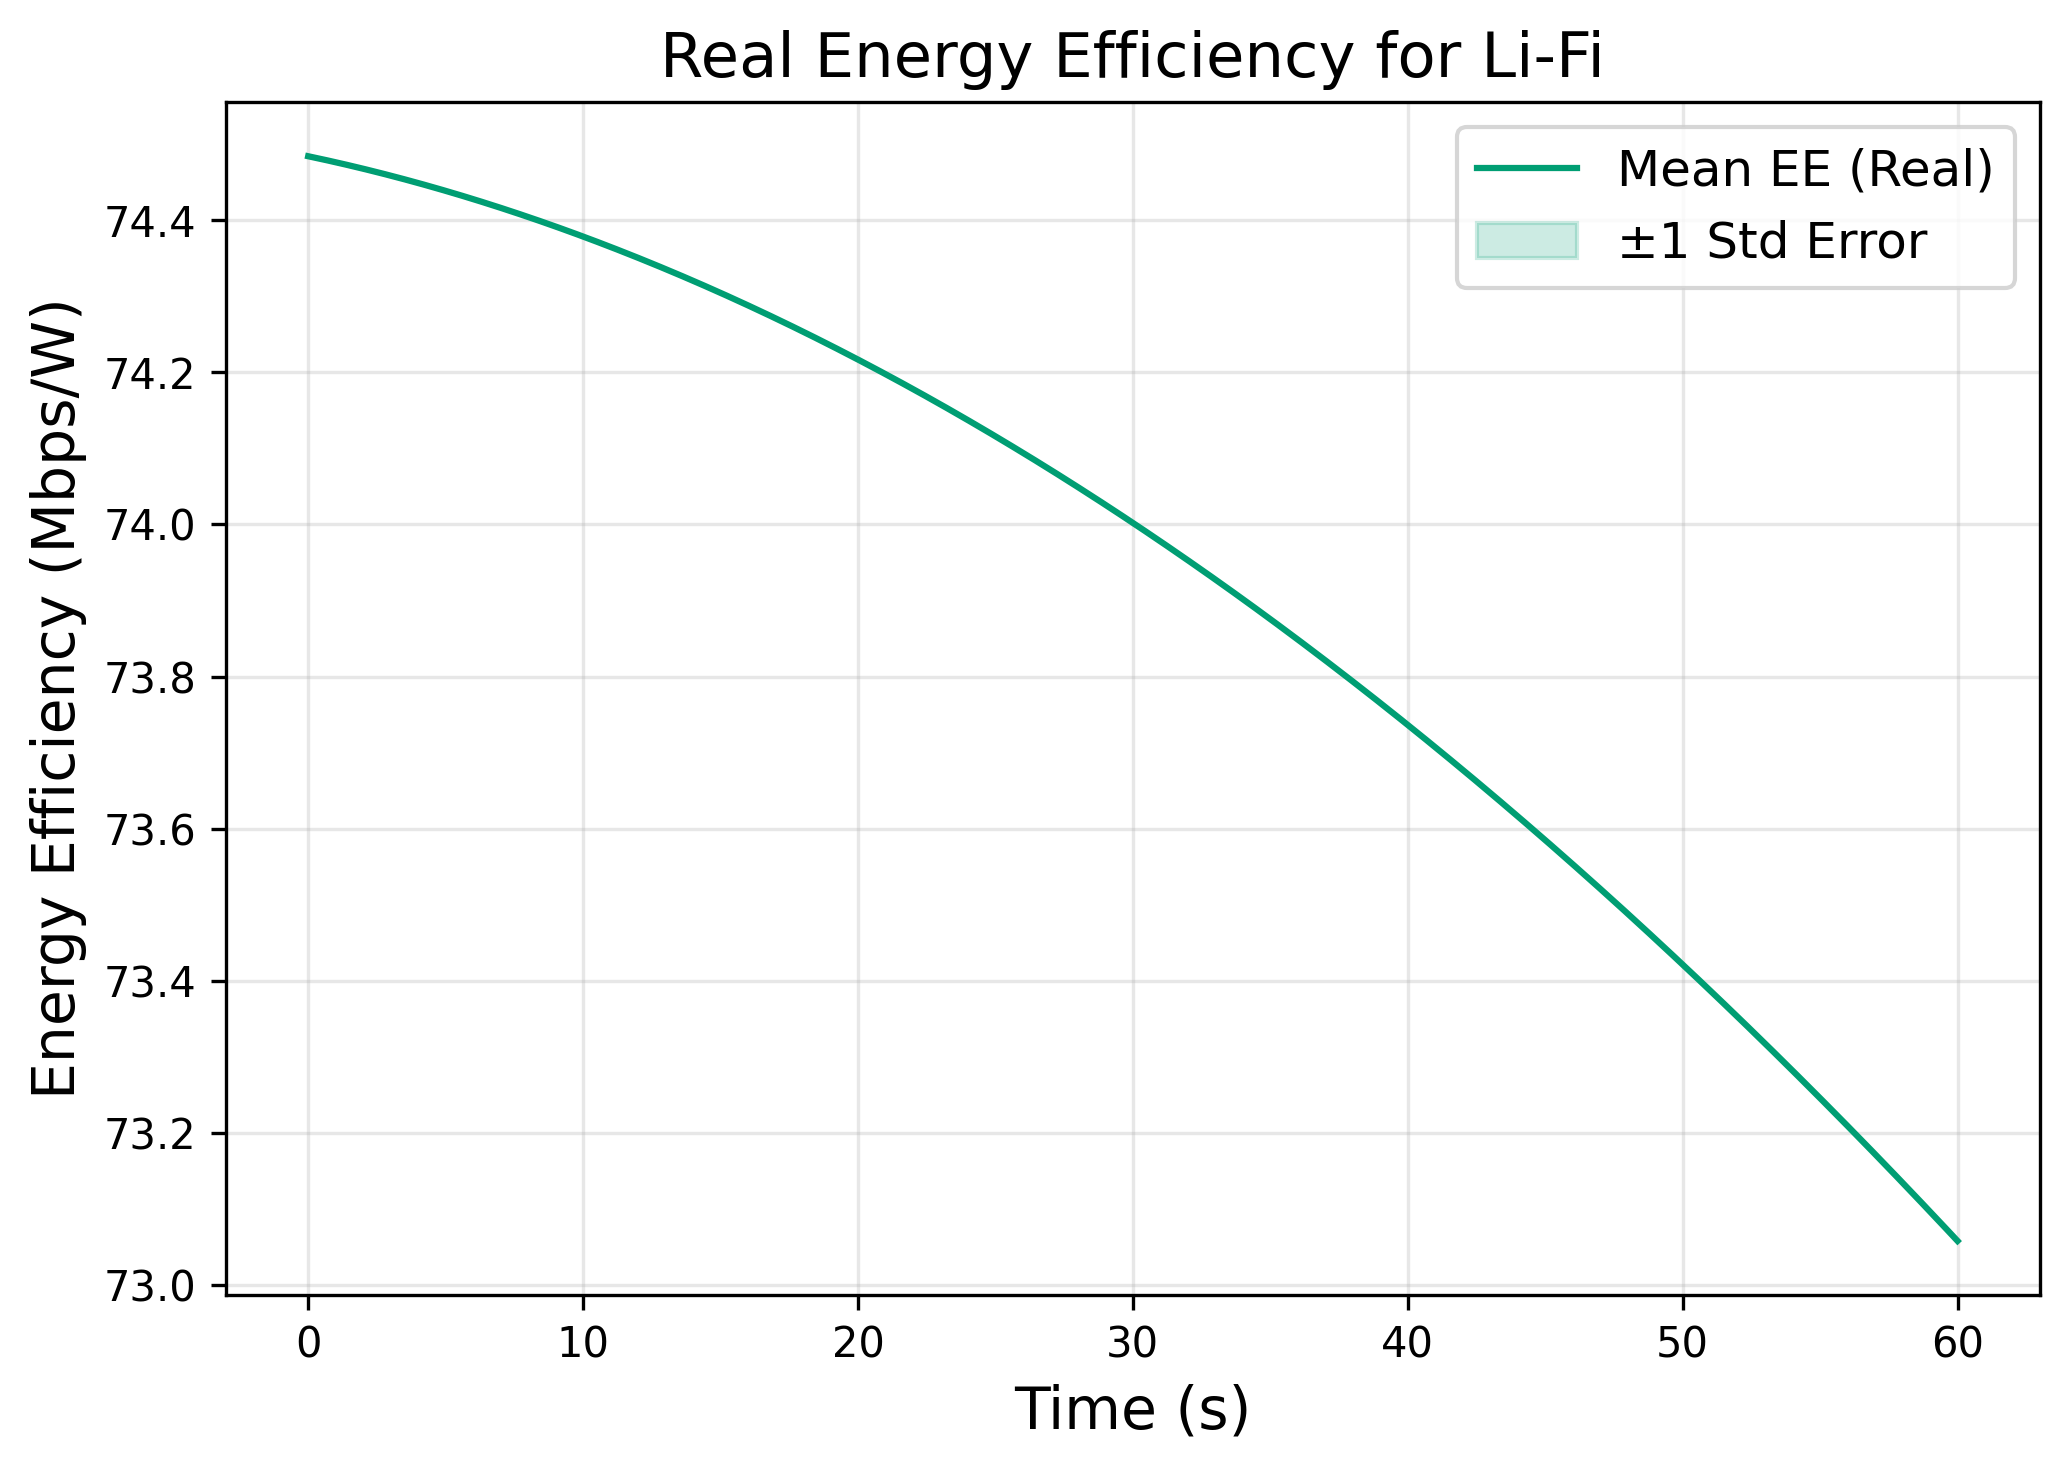

In [19]:
plt.figure(figsize=(7,5), dpi=300)
plt.plot(time_arr_LED, mean_EE, color='#009E73', label='Mean EE (Real)')
plt.fill_between(time_arr_LED, mean_EE - std_err_EE, mean_EE + std_err_EE, color='#009E73', alpha=0.2, label='±1 Std Error')
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Energy Efficiency (Mbps/W)', fontsize=14)
plt.title('Real Energy Efficiency for Li-Fi', fontsize=15)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Caption: "Mean energy efficiency (Mbps/W) in realistic conditions, averaged over 20 runs with ±1 standard error."

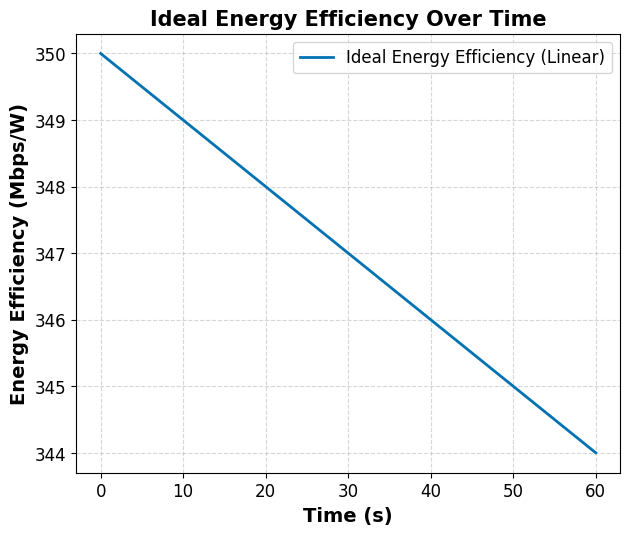

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming time_arr_LED is your time array for 60 seconds
start_EE = 350  # Mbps/W at time 0
end_EE = 344    # Mbps/W at time 60

# Create linear decline array
EE_ideal_linear = np.linspace(start_EE, end_EE, len(time_arr_LED))

plt.figure(figsize=(12,10))

# Other subplots unchanged...

# Replace your EE subplot with this:
plt.subplot(2,2,3)
plt.plot(time_arr_LED, EE_ideal_linear, color='#0072B2', linewidth=2, label='Ideal Energy Efficiency (Linear)')
plt.xlabel('Time (s)', fontsize=14, fontweight='bold')
plt.ylabel('Energy Efficiency (Mbps/W)', fontsize=14, fontweight='bold')
plt.title("Ideal Energy Efficiency Over Time", fontsize=15, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.5, linestyle='--')
plt.legend(fontsize=12)

# Keep other subplots as they are...

plt.tight_layout()
plt.show()

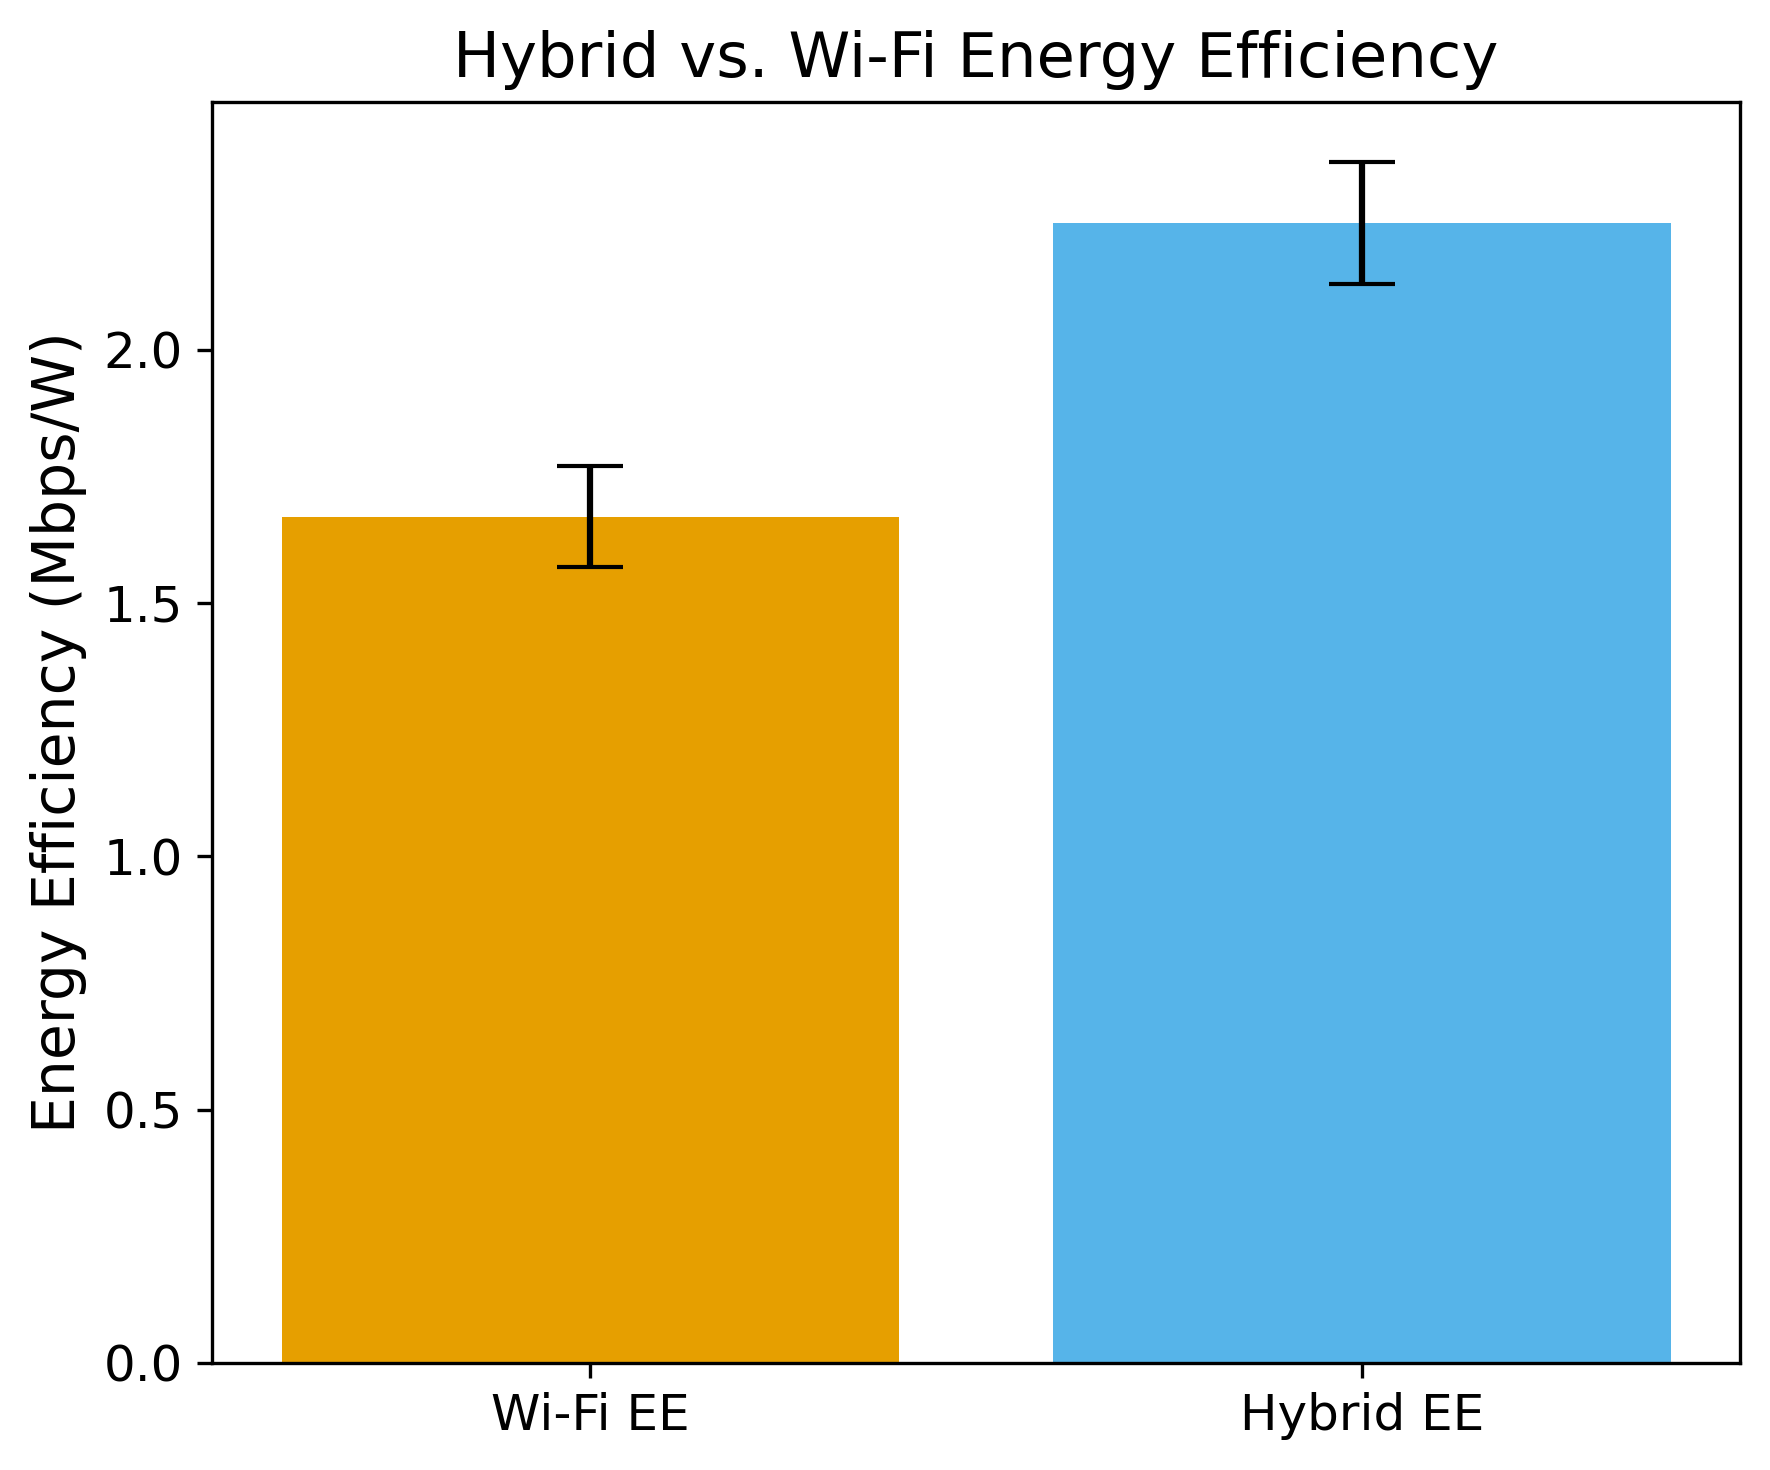

In [20]:
means = [1.67, 2.25]  # Example: [Wi-Fi EE, Hybrid EE]
std_errs = [0.1, 0.12]  # Replace with your actual std error values
labels = ['Wi-Fi EE', 'Hybrid EE']
colors = ['#E69F00', '#56B4E9']  # Colorblind-friendly

plt.figure(figsize=(6,5), dpi=300)
bars = plt.bar(labels, means, yerr=std_errs, capsize=8, color=colors)
plt.ylabel('Energy Efficiency (Mbps/W)', fontsize=14)
plt.title('Hybrid vs. Wi-Fi Energy Efficiency', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
# Caption: "Bar chart comparing mean energy efficiency (±1 standard error) for Wi-Fi and hybrid systems over 20 runs."